In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Primero comprobamos que no hay valores nulos en los datos recibidos
df = pd.read_csv("../Datos/Original/tcga_simple_train.csv")

print(df.isnull().sum())

patient_id    0
text          0
t             0
dtype: int64


Como podemos observar, no tenemos ningun valor nulo en el dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5158 entries, 0 to 5157
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  5158 non-null   str  
 1   text        5158 non-null   str  
 2   t           5158 non-null   str  
dtypes: str(3)
memory usage: 17.7 MB


In [4]:
#Analizamos si hay algun dato duplicado que no deseemos para posteriores calculos
print(f"Total de filas: {len(df)}")
print(f"Pacientes duplicados: {df['patient_id'].duplicated().sum()}")
print(f"Textos duplicados: {df['text'].duplicated().sum()}")

Total de filas: 5158
Pacientes duplicados: 0
Textos duplicados: 0


Distribucion de las diferentes clases del dataset:
t
T1    1302
T2    1752
T3    1583
T4     521
Name: count, dtype: int64
t
T1    0.252423
T2    0.339667
T3    0.306902
T4    0.101008
Name: count, dtype: float64


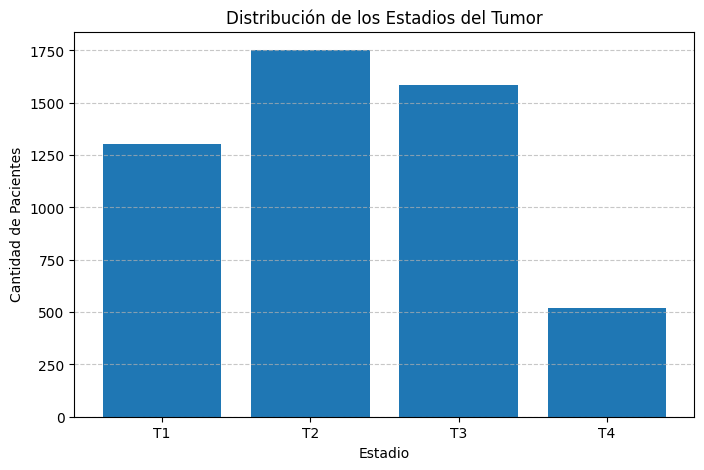

In [ ]:

'''
Calcular la distribucion de las diferentes clases que tenemos en los datos, mostrando tanto la cantidad total como la proporcion respecto a casos totales
'''


row = df.shape[0]
clase = df['t'].value_counts().sort_index()
total = df["t"].value_counts().sum()
distribucion = clase / total

print("Distribucion de las diferentes clases del dataset:")
print(clase)
print(distribucion)

plt.figure(figsize=(8, 5))

plt.bar(clase.index, clase.values)

plt.title('Distribución de los Estadios del Tumor')
plt.xlabel('Estadio')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostramos el gráfico
plt.show()

El dataset está relativamente bien balanceado entre los estadios T1, T2 y T3, aunque hay una clara minoría de casos en el estadio T4, lo cual es normal en contextos médicos (los tumores más grandes o invasivos son menos frecuentes), pero habrá que tenerlo en cuenta al entrenar modelos predictivos.

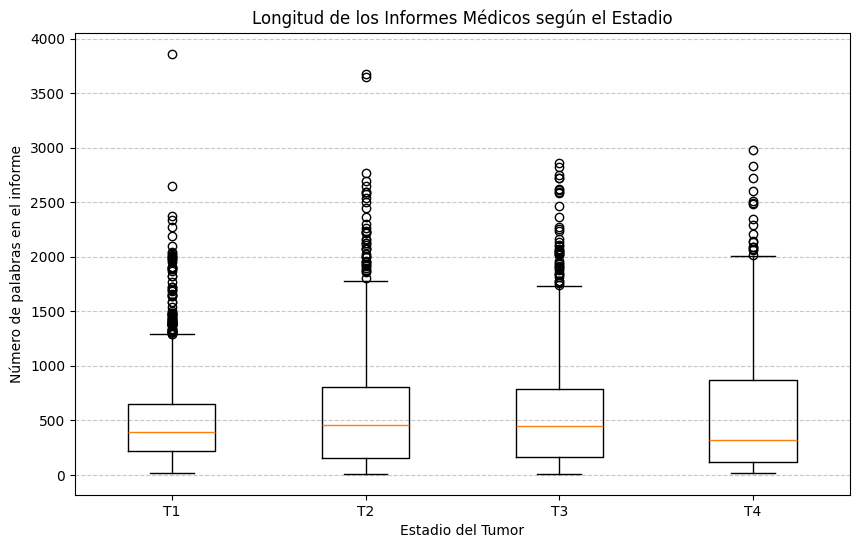

In [6]:
# Contamos cuántas palabras separadas por espacio hay en cada texto dependiendo del estadio del tumor

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

datos_t1 = df[df['t'] == 'T1']['word_count']
datos_t2 = df[df['t'] == 'T2']['word_count']
datos_t3 = df[df['t'] == 'T3']['word_count']
datos_t4 = df[df['t'] == 'T4']['word_count']

datos_para_grafico = [datos_t1, datos_t2, datos_t3, datos_t4]
etiquetas = ['T1', 'T2', 'T3', 'T4']
plt.figure(figsize=(10, 6))

cajas = plt.boxplot(datos_para_grafico, tick_labels=etiquetas)

plt.title('Longitud de los Informes Médicos según el Estadio')
plt.xlabel('Estadio del Tumor')
plt.ylabel('Número de palabras en el informe')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

###  Conclusiones del Análisis de Longitud de Textos

 **Medianas similares:** Los informes de los estadios T1, T2 y T3 tienen una longitud parecida (400-450 palabras). Curiosamente, la mediana del estadio más grave (T4) es ligeramente inferior, lo que indica informes más directos o concisos.

 **Gran solapamiento:** Las distribuciones de los cuatro estadios se superponen casi por completo. Esto demuestra que **la longitud del texto por sí sola no es un buen indicador para predecir el estadio del tumor**.

 **Presencia de *Outliers*:** Se observan numerosos valores atípicos (informes de más de 3.000 palabras). Sorprendentemente, los historiales más extensos se encuentran en los estadios iniciales (T1 y T2), demostrando que la complejidad del informe no escala con la gravedad.
 
 **Conclusión final:** Dado que contar palabras no es suficiente, se hace indispensable aplicar técnicas de **Procesamiento de Lenguaje Natural (NLP)** para extraer el significado, el contexto y los términos médicos clave de cada texto.